# 2차 Funnel — 스케일링 · 전처리 모듈 테스트

**목적**: `strategy_2nd_preprocessing.md` / `strategy_2nd_ensemble.md`에서 정의한 신규 전처리 모듈 sanity check.

**검증 흐름**
1. cleaning + outlier (기존)
2. IsoForest anomaly score 추가
3. 스케일링 전 baseline 진단 (skew / kurtosis / D'Agostino K²)
4. 스케일링 4종 비교 (robust / power / quantile / hybrid) — feature별 winner 집계
5. hybrid_scale 실제 적용 (train fit → train/val/test transform)
6. LDS sanity check (`compute_lds_weights`, 회귀 학습은 2차 노트북에서)

## 1. 환경 설정 + 데이터 로드

In [1]:
# ============================================================
# 환경 설정 + 전체 import + 데이터 로드 (Colab / Local 공통)
# ============================================================
import os, sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 프로젝트 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, OUTPUT_DIR
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import rmse

# --- 2_preprocessing 모듈 (cleaning / outlier / scaling / sample_weight) ---
# setup.py는 프로젝트 루트만 path에 추가하므로 2_preprocessing은 명시적으로 추가
_PP_PATH = os.path.join(PROJECT_ROOT, '2_preprocessing')
if _PP_PATH not in sys.path:
    sys.path.insert(0, _PP_PATH)

from cleaning import run_cleaning, binarize_degenerate
from outlier import run_outlier_treatment, multivariate_anomaly_score
from scaling import HybridScaler, hybrid_scale
from sample_weight import compute_lds_weights

# --- 외부 라이브러리 (스케일링 4종 비교 + 정규성 검정) ---
from sklearn.preprocessing import RobustScaler, PowerTransformer, QuantileTransformer
from scipy.stats import normaltest

# --- 웨이퍼맵 기반 사전 제외 feature ---
# [1_eda/wafer_map_image/★분류완료/1_꼭빼야함]에 수동 분류된 컬럼들.
# wafer map 패턴상 target과 무관/유해 판정 → cleaning 등 모든 전처리 이전에 제거.
EXCLUDE_COLS = [
    'X124', 'X300', 'X301',
    'X443', 'X444', 'X447', 'X448', 'X449',
    'X451', 'X452', 'X455', 'X456', 'X457', 'X458', 'X459', 'X460',
    'X463', 'X464',
    'X503', 'X504', 'X505', 'X506',
    'X517',
    'X658', 'X659', 'X671', 'X672',
    'X674', 'X675', 'X676', 'X677',
    'X680', 'X687',
    'X1074', 'X1078',
]

# --- 데이터 로드 ---
xs, ys = load_all()
feat_cols_raw = get_feat_cols(xs)
xs_dict = split_xs(xs)

# 웨이퍼맵 사전 제외 적용
feat_cols = [c for c in feat_cols_raw if c not in set(EXCLUDE_COLS)]
n_removed = len(feat_cols_raw) - len(feat_cols)

print(f'Feature: {len(feat_cols_raw)} → {len(feat_cols)}  '
      f'(웨이퍼맵 사전 제외 {n_removed}개)')
print(f'Die 수  : train={len(xs_dict["train"]):,}, '
      f'val={len(xs_dict["validation"]):,}, '
      f'test={len(xs_dict["test"]):,}')
print(f'Unit 수 : train={len(ys["train"]):,}, '
      f'val={len(ys["validation"]):,}, '
      f'test={len(ys["test"]):,}')

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
Feature: 1087 → 1052  (웨이퍼맵 사전 제외 35개)
Die 수  : train=104,988, val=34,996, test=34,996
Unit 수 : train=26,247, val=8,749, test=8,749


## 2. Cleaning 적용

baseline best trial 값 기본 세팅. 다른 값으로 실험하려면 `cleaning_args`만 수정.

| 단계 | 내용 |
|---|---|
| 1 | 상수/극저분산 제거 (`const_threshold=1e-6`) |
| 2 | 고결측 제거 (`missing_threshold=0.5`) |
| 3 | 중복 컬럼 제거 (`remove_duplicates=True`) |
| 4 | 고상관 제거 1차 (`corr_threshold=0.94`, keep=`target_corr`) |
| 5 | 결측 imputation (`spatial`, `max_dist=2.0`) |
| 6 | 고상관 제거 2차 (`post_impute_corr_threshold=0.98`, keep=`std`) |

In [2]:
cleaning_args = dict(
    const_threshold=1e-6,
    missing_threshold=0.5,
    remove_duplicates=True,
    corr_threshold=0.94,
    corr_keep_by='target_corr',
    add_indicator=False,
    indicator_threshold=0.01,
    imputation_method='spatial',
    spatial_max_dist=2.0,
    post_impute_corr_threshold=0.98,
    post_impute_corr_keep_by='std',
)

xs_train, xs_val, xs_test, clean_cols, clean_report = run_cleaning(
    xs, feat_cols, xs_dict,
    ys_train=ys['train'],
    **cleaning_args,
)

print(f'\n── Cleaning 결과 ──')
print(f'원본 feature : {len(feat_cols)}')
print(f'정리 후      : {len(clean_cols)}  (제거 {len(feat_cols) - len(clean_cols)}개)')
print(f'xs_train     : {xs_train.shape}')
print(f'xs_val       : {xs_val.shape}')
print(f'xs_test      : {xs_test.shape}')

remain_na = xs_train[clean_cols].isna().sum().sum()
print(f'train 결측 잔존: {remain_na} (0이어야 정상)')

클리닝 파이프라인 시작
원본 feature 수: 1052
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 947개
    컬럼: 1052 → 947 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=50%
  제거: 4개, 잔여: 943개
    컬럼: 947 → 943 (4개 제거)
    DataFrame: (104988, 982)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 917개
    컬럼: 943 → 917 (26개 제거)
    DataFrame: (104988, 956)

[고상관 제거] threshold=0.94, keep_by=target_corr (|target 상관| 우선, 동률이면 std (unit-level merge n=26,247))
  제거: 227개, 잔여: 690개
    컬럼: 917 → 690 (227개 제거)
    DataFrame: (104988, 729)

[공간 보간 imputation] 총 결측: 629,322
  train-only 모드: train 104,988 / 전체 174,980 행
  1단계 (공간 보간, dist<=2.0): 79,479개 채움 → 잔여: 549,843
  2단계 (lot 평균, train 기준): 468,647개 채움 → 잔여: 81,196
  3단계 (train 전체 평균): 81,196개 채움 → 잔여: 0

  [요약] 629,322 → 공간(79,479) → lot(468,647) → 전체(81,196) → 잔여(0)

[고상관 제거] threshold=0.98, keep_by=std (std)
  제거: 0개, 잔여: 690개
    [고상관 제거 2차 / imputation 후] threshold=0.98
    컬럼: 690 → 690 (0개 제거)
    DataFrame: (104988, 729)

클리닝 완료: 1052 → 690 features (

## 2.5 Degenerate feature → Binary 변환 (2차 신규)

**변환 조건 (OR)**:
1. 최빈값 비율 `top% > 95%` (한 값에 거의 몰린 feature)
2. 고유값 `nunique ≤ 5` (사실상 이산형 feature)

둘 중 하나만 충족해도 → **Yes/No (0/1) 이진 indicator**로 단순화.

- 대상: `clean_cols`, train 기준 판정
- 변환: `(X == 최빈값) → 0, 그 외 → 1` (int8)
- 위치: **cleaning 이후, outlier 이전** (이진화 후에는 winsorize 거의 무의미)
- 근거:
  - EDA의 "Y=0 vs Y>0 구분이 주요 신호" — degenerate feature의 "평범/특이" 구조와 정합
  - 3-split 간 top% 분포 일관성 확인됨 (셀 24) → train 기준 binarize가 val/test에도 안정 적용

In [3]:
# ============================================================
# Degenerate feature Binarize (top% > 95% OR nunique ≤ 5)
# ============================================================
APPLY_BINARIZE      = True           # False → 이진화 스킵
TOP_VALUE_THRESHOLD = 0.95           # 최빈값 비율 상한 (완화: 0.99 → 0.95)
MAX_UNIQUE          = 5              # nunique ≤ 5 무조건 binarize

if APPLY_BINARIZE:
    xs_train, xs_val, xs_test, binarize_report = binarize_degenerate(
        xs_train, xs_val, xs_test, clean_cols,
        top_value_threshold=TOP_VALUE_THRESHOLD,
        max_unique=MAX_UNIQUE,
    )
    print(f'\n→ binary 변환 완료: {binarize_report["n_converted"]}개 feature')
    print(f'  clean_cols 수는 유지 ({len(clean_cols)}개), 값만 0/1로 바뀜')
else:
    binarize_report = {'n_converted': 0, 'converted': []}
    print('[SKIP] Binarize 스킵')

# sanity
assert xs_train[clean_cols].isna().sum().sum() == 0
assert not np.isinf(xs_train[clean_cols].values).any()

[Binarize] top% > 95% OR nuniq ≤ 5 → binary 변환
  변환 대상: 47개 / 690개
  X302: mode=28 (top%=73.43%, nuniq=3) → 0/1  [nuniq]
  X364: mode=0 (top%=96.57%, nuniq=3) → 0/1  [top%+nuniq]
  X365: mode=0 (top%=88.34%, nuniq=3) → 0/1  [nuniq]
  X366: mode=0 (top%=97.10%, nuniq=3) → 0/1  [top%+nuniq]
  X367: mode=0 (top%=96.16%, nuniq=3) → 0/1  [top%+nuniq]
  X368: mode=0 (top%=98.51%, nuniq=3) → 0/1  [top%+nuniq]
  X369: mode=0 (top%=95.03%, nuniq=3) → 0/1  [top%+nuniq]
  X372: mode=0 (top%=97.55%, nuniq=5) → 0/1  [top%+nuniq]
  X373: mode=0 (top%=92.25%, nuniq=3) → 0/1  [nuniq]
  X374: mode=0 (top%=99.03%, nuniq=3) → 0/1  [top%+nuniq]
  X375: mode=0 (top%=99.52%, nuniq=3) → 0/1  [top%+nuniq]
  X378: mode=12 (top%=97.19%, nuniq=7) → 0/1  [top%]
  X379: mode=77 (top%=59.32%, nuniq=5) → 0/1  [nuniq]
  X384: mode=0 (top%=99.88%, nuniq=3) → 0/1  [top%+nuniq]
  X386: mode=3 (top%=85.12%, nuniq=5) → 0/1  [nuniq]
  X388: mode=4 (top%=70.51%, nuniq=5) → 0/1  [nuniq]
  X467: mode=1 (top%=99.72%, nuniq=4) 

## 3. Outlier 처리 적용

baseline best trial 값 기본 세팅 (`winsorize`, `upper_pct=0.99`).

In [4]:
outlier_args = dict(
    method='winsorize',
    lower_pct=0.0,
    upper_pct=0.99,
)

xs_train, xs_val, xs_test, outlier_report = run_outlier_treatment(
    xs_train, xs_val, xs_test, clean_cols,
    **outlier_args,
)

print(f'\n── Outlier 처리 결과 ──')
print(f'method       : {outlier_args["method"]}')
print(f'xs_train     : {xs_train.shape}')

assert xs_train[clean_cols].isna().sum().sum() == 0, 'train에 결측이 남음'
assert not np.isinf(xs_train[clean_cols].values).any(), 'train에 inf가 있음'
print('NaN / Inf 없음 — 스케일링 진입 가능')

이상치 처리 파이프라인 시작 (method=winsorize)
[이상치 탐지] IQR × 1.5
  이상치 > 5%: 120개
  이상치 > 10%: 61개
[Winsorization] lower=0%, upper=99%
  적용 feature: 690개

이상치 처리 완료 (method=winsorize)
  train: (104988, 729)

── Outlier 처리 결과 ──
method       : winsorize
xs_train     : (104988, 729)
NaN / Inf 없음 — 스케일링 진입 가능


## 4. IsoForest anomaly score 추가

strategy_2nd_preprocessing.md §4.1의 `multivariate_anomaly_score()` 적용. **die-level 파생 피처 1컬럼 추가** (제거 아님).

- 원본 분포 기준 이상도 측정이 자연스러우므로 **스케일링 이전**에 적용
- 생성된 `iso_anomaly_score` 컬럼은 뒤 스케일링에 함께 들어감 (스케일 정렬)
- `APPLY_ISO=False`로 두면 스킵하고 marginal 비교 가능

In [5]:
APPLY_ISO = True   # False → IsoForest 스킵

iso_args = dict(
    contamination='auto',
    n_estimators=200,
    max_samples='auto',   # 메모리 이슈 있으면 10000 등 int로 제한
    score_col='iso_anomaly_score',
    random_state=SEED,
)

if APPLY_ISO:
    xs_train, xs_val, xs_test, feat_cols_scale, iso_report = multivariate_anomaly_score(
        xs_train, xs_val, xs_test, clean_cols, **iso_args,
    )
    print(f'\n→ feat_cols_scale: {len(clean_cols)} → {len(feat_cols_scale)} '
          f'(+{len(feat_cols_scale) - len(clean_cols)} iso_anomaly_score)')
else:
    feat_cols_scale = list(clean_cols)
    print('[SKIP] IsoForest 스킵 — feat_cols_scale = clean_cols')

print(f'스케일링 대상 feature 수: {len(feat_cols_scale)}')

[IsoForest] anomaly score 컬럼 추가: 'iso_anomaly_score'
  n_estimators=200, contamination=auto
  train score 범위: [-0.1054, 0.1036]
  val   score 범위: [-0.1029, 0.1025]
  test  score 범위: [-0.1083, 0.1031]

→ feat_cols_scale: 690 → 691 (+1 iso_anomaly_score)
스케일링 대상 feature 수: 691


## 5. 스케일링 전 baseline 진단

스케일링 전/후 비교 기준을 `train` 기준으로 측정.

| 지표 | 기준 | 해석 |
|---|---|---|
| `\|skew\|` | \<0.5 정규 근사, 2 편중, \>10 극단 | 작을수록 대칭 |
| `\|excess kurt\|` | 0 정규, \>3 heavy-tail | 작을수록 정규 |
| D'Agostino K² p | \>0.05 정규 (귀무 기각 X) | 표본 큰 경우 엄격 → 참고용 |

**정규성 양호 판정**: `|skew|<0.5 AND |excess kurt|<1` (경험적 기준, 표본 크기에 robust)

In [6]:
def diagnose_train(X_train, feat_cols, label):
    """train 기준 feature별 skew/kurtosis/normaltest p-value 반환"""
    arr = X_train[feat_cols].values  # scipy normaltest는 float32도 허용 (내부 cast)
    # pandas skew/kurt는 bias-corrected, kurtosis는 excess (정규=0)
    skews = pd.Series(X_train[feat_cols].skew().values, index=feat_cols)
    kurts = pd.Series(X_train[feat_cols].kurtosis().values, index=feat_cols)
    # D'Agostino's K² (N>=20이면 가능, nan_policy='omit')
    _, pvals = normaltest(arr, nan_policy='omit', axis=0)
    return pd.DataFrame({
        'skew':     skews.values,
        'abs_skew': skews.abs().values,
        'kurt':     kurts.values,
        'abs_kurt': kurts.abs().values,
        'norm_p':   pvals,
    }, index=feat_cols)


def summarize(diag, label):
    """요약 통계 한 줄 출력"""
    s = diag['abs_skew']
    k = diag['abs_kurt']
    normlike = (s < 0.5) & (k < 1.0)   # 경험적 정규 근사 기준
    print(f'[{label:>8s}] '
          f'|skew| mean={s.mean():.3f} median={s.median():.3f} '
          f'max={s.max():.3f} | '
          f'|skew|>2 : {int((s>2).sum())}/{len(s)} | '
          f'|skew|>10: {int((s>10).sum())}/{len(s)} | '
          f'정규근사(|skew|<0.5 & |kurt|<1): {int(normlike.sum())}/{len(s)} '
          f'({normlike.mean()*100:.1f}%)')


diag_base = diagnose_train(xs_train, feat_cols_scale, 'base')
print(f'진단 대상 feature 수: {len(feat_cols_scale)}')
summarize(diag_base, 'base')

# 극단 feature 몇 개 미리 확인
print('\n── |skew| top 10 (baseline) ──')
print(diag_base.nlargest(10, 'abs_skew')[['skew', 'kurt', 'norm_p']].round(3))

진단 대상 feature 수: 691
[    base] |skew| mean=2.982 median=0.418 max=245.562 | |skew|>2 : 126/691 | |skew|>10: 28/691 | 정규근사(|skew|<0.5 & |kurt|<1): 299/691 (43.3%)

── |skew| top 10 (baseline) ──
          skew       kurt  norm_p
X1029 -245.562  65510.477     0.0
X1030 -172.209  41832.957     0.0
X1033 -161.355  32610.662     0.0
X1032 -156.584  28081.064     0.0
X996  -139.714  19924.375     0.0
X1031  -94.541  14075.617     0.0
X959   -41.710   3319.385     0.0
X958   -28.924   2036.232     0.0
X827   -28.784   2175.660     0.0
X1003  -24.982    699.630     0.0


## 6. 스케일링 4종 비교

방법: `robust` / `power(Yeo-Johnson)` / `quantile` / `hybrid(ours)`.

**메모리 전략**: 각 방법을 **순차 적용 → train만 진단 → 데이터 해제**. 4배 복사 피함.

- `robust`: `(x - median) / IQR`  (이상치 강건, 정규화 X)
- `power`: Yeo-Johnson + standardize (파라메트릭)
- `quantile`: rank 기반 `normal` 출력 (heavy-tail 자동 평탄화)
- `hybrid`: `|skew|>10 → quantile`, 나머지 → `power` (ours)

In [7]:
SKEW_THRESHOLD = 5.0    # hybrid 기준 — 10.0 → 5.0 (선형 모델 친화, 옵션 A)


def apply_one(method, train_df, feat_cols):
    """한 방법만 train에 fit+transform → scaled DataFrame 반환 (val/test 안 건드림)"""
    tr = train_df[feat_cols].copy()
    if method == 'robust':
        sc = RobustScaler().fit(tr)
        tr_scaled = pd.DataFrame(sc.transform(tr), columns=feat_cols, index=tr.index)
    elif method == 'power':
        sc = PowerTransformer(method='yeo-johnson', standardize=True).fit(tr)
        tr_scaled = pd.DataFrame(sc.transform(tr), columns=feat_cols, index=tr.index)
    elif method == 'quantile':
        n_q = min(1000, len(tr))
        sc = QuantileTransformer(n_quantiles=n_q, output_distribution='normal',
                                 subsample=int(1e6), random_state=SEED).fit(tr)
        tr_scaled = pd.DataFrame(sc.transform(tr), columns=feat_cols, index=tr.index)
    elif method == 'hybrid':
        sc = HybridScaler(skew_threshold=SKEW_THRESHOLD, random_state=SEED).fit(tr, feat_cols)
        tr_scaled = sc.transform(tr, inplace=False)
    else:
        raise ValueError(method)
    return tr_scaled, sc


diags  = {'base': diag_base}
scalers = {}

for m in ['robust', 'power', 'quantile', 'hybrid']:
    print(f'\n── {m} ──')
    tr_scaled, sc = apply_one(m, xs_train, feat_cols_scale)
    diags[m]   = diagnose_train(tr_scaled, feat_cols_scale, m)
    scalers[m] = sc
    summarize(diags[m], m)
    del tr_scaled   # 메모리 해제

print('\n4종 비교 완료')


── robust ──
[  robust] |skew| mean=2.982 median=0.418 max=245.562 | |skew|>2 : 126/691 | |skew|>10: 28/691 | 정규근사(|skew|<0.5 & |kurt|<1): 299/691 (43.3%)

── power ──
[   power] |skew| mean=0.824 median=0.041 max=113.708 | |skew|>2 : 46/691 | |skew|>10: 3/691 | 정규근사(|skew|<0.5 & |kurt|<1): 444/691 (64.3%)

── quantile ──
[quantile] |skew| mean=0.547 median=0.053 max=9.038 | |skew|>2 : 36/691 | |skew|>10: 0/691 | 정규근사(|skew|<0.5 & |kurt|<1): 459/691 (66.4%)

── hybrid ──
[HybridScaler.fit] skew_threshold=5.0
  Binary passthrough: 47개 (nunique ≤ 2, 변환 없음)
  Quantile 적용     : 51개 (|skew| > 5.0)
  Power 적용        : 593개 (Yeo-Johnson + standardize)
[  hybrid] |skew| mean=0.561 median=0.034 max=113.708 | |skew|>2 : 34/691 | |skew|>10: 1/691 | 정규근사(|skew|<0.5 & |kurt|<1): 470/691 (68.0%)

4종 비교 완료


## 7. 후 진단 요약 테이블

method × 지표 요약표.

- `|skew| mean/median/max`: 작을수록 대칭 개선
- `|skew|>2 개수`: 심한 편중 잔존 수
- `|skew|>10 개수`: 극단 편중 잔존 수 (원본 대비 감소해야 정상)
- `정규근사율`: `|skew|<0.5 AND |kurt|<1` 통과 feature 비율

In [8]:
def row_summary(diag):
    s = diag['abs_skew']
    k = diag['abs_kurt']
    normlike = (s < 0.5) & (k < 1.0)
    return {
        '|skew| mean':   round(float(s.mean()),   4),
        '|skew| median': round(float(s.median()), 4),
        '|skew| max':    round(float(s.max()),    4),
        '|skew|>0.5':    int((s > 0.5).sum()),
        '|skew|>2':      int((s > 2).sum()),
        '|skew|>10':     int((s > 10).sum()),
        '|kurt| mean':   round(float(k.mean()),   4),
        '|kurt| median': round(float(k.median()), 4),
        '정규근사수':       int(normlike.sum()),
        '정규근사율(%)':    round(float(normlike.mean()) * 100, 2),
    }


summary = pd.DataFrame({m: row_summary(d) for m, d in diags.items()}).T
print('── Method × 지표 요약 ──')
print(summary.to_string())

# 가장 개선된 method (정규근사율 최대 + |skew|>2 최소)
best_normlike = summary['정규근사율(%)'].idxmax()
best_tail     = summary['|skew|>2'].idxmin()
print(f'\n정규근사율 최고   : {best_normlike} ({summary.loc[best_normlike, "정규근사율(%)"]:.2f}%)')
print(f'|skew|>2 최소    : {best_tail} ({summary.loc[best_tail, "|skew|>2"]}개)')

── Method × 지표 요약 ──
          |skew| mean  |skew| median  |skew| max  |skew|>0.5  |skew|>2  |skew|>10  |kurt| mean  |kurt| median  정규근사수  정규근사율(%)
base           2.9817         0.4175    245.5624       322.0     126.0       28.0     341.1280         1.0856  299.0     43.27
robust         2.9817         0.4175    245.5624       322.0     126.0       28.0     341.1280         1.0856  299.0     43.27
power          0.8235         0.0407    113.7083       136.0      46.0        3.0      45.6835         0.5159  444.0     64.25
quantile       0.5471         0.0527      9.0378       199.0      36.0        0.0       2.2207         0.1369  459.0     66.43
hybrid         0.5606         0.0335    113.7083       121.0      34.0        1.0      21.9075         0.4159  470.0     68.02

정규근사율 최고   : hybrid (68.02%)
|skew|>2 최소    : hybrid (34.0개)


## 8. feature별 winner 집계

각 feature별로 `|skew|`가 가장 작아지는 method를 찾아 집계.

- method별 winner 수 → 어떤 변환이 어느 feature 타입에 잘 맞는지 보임
- **잔존 문제 feature**: 4종 중 **어느 방법으로도 `|skew|>2`** 인 feature → 추가 조치 필요 후보

In [9]:
# method별 abs_skew 매트릭스 (행=feature, 열=method)
method_list = ['base', 'robust', 'power', 'quantile', 'hybrid']
abs_skew_mat = pd.DataFrame(
    {m: diags[m]['abs_skew'] for m in method_list},
    index=feat_cols_scale,
)

# base 제외한 4종 중 winner
candidate_methods = ['robust', 'power', 'quantile', 'hybrid']
winner = abs_skew_mat[candidate_methods].idxmin(axis=1)
winner_min_skew = abs_skew_mat[candidate_methods].min(axis=1)

winner_counts = winner.value_counts().reindex(candidate_methods, fill_value=0)
print('── feature별 winner 집계 (|skew| 최소 기준) ──')
for m in candidate_methods:
    pct = winner_counts[m] / len(winner) * 100
    print(f'  {m:>9s}: {winner_counts[m]:4d}개 ({pct:5.1f}%)')

# 잔존 문제 feature: 4종 중 어느 방법도 |skew|>2
min_abs_skew_any = abs_skew_mat[candidate_methods].min(axis=1)
residual = min_abs_skew_any > 2.0
print(f'\n── 잔존 문제 feature (4종 중 best도 |skew|>2) ──')
print(f'  개수: {int(residual.sum())} / {len(residual)} ({residual.mean()*100:.2f}%)')
if residual.sum() > 0:
    preview = abs_skew_mat.loc[residual].sort_values('base', ascending=False).head(20)
    print(preview.round(3))

# base 대비 개선 폭 (하이브리드)
improve = diag_base['abs_skew'] - diags['hybrid']['abs_skew']
print(f'\n── hybrid 개선 폭 (base - hybrid) ──')
print(f'  평균 Δ|skew|: {improve.mean():.4f}')
print(f'  중앙 Δ|skew|: {improve.median():.4f}')
print(f'  개선 feature(Δ>0)  : {int((improve > 0).sum())} / {len(improve)}')
print(f'  악화 feature(Δ<0)  : {int((improve < 0).sum())} / {len(improve)}')

── feature별 winner 집계 (|skew| 최소 기준) ──
     robust:   70개 ( 10.1%)
      power:  373개 ( 54.0%)
   quantile:  247개 ( 35.7%)
     hybrid:    1개 (  0.1%)

── 잔존 문제 feature (4종 중 best도 |skew|>2) ──
  개수: 29 / 691 (4.20%)
       base  robust  power  quantile  hybrid
X954  9.038   9.038  9.038     9.038   9.038
X921  8.901   8.901  8.901     8.901   8.901
X368  8.020   8.020  8.020     8.020   8.020
X922  7.953   7.953  7.953     7.953   7.953
X514  7.074   7.074  7.074     7.074   7.074
X945  7.069   7.069  7.069     7.069   7.069
X923  6.548   6.548  6.548     6.548   6.548
X981  6.401   6.401  3.553     3.583   3.583
X963  6.234   6.234  4.498     3.550   3.550
X372  6.154   6.154  6.154     6.154   6.154
X636  5.928   5.928  5.928     5.928   5.928
X516  5.928   5.928  5.928     5.928   5.928
X378  5.716   5.716  5.716     5.716   5.716
X366  5.611   5.611  5.611     5.611   5.611
X364  5.118   5.118  5.118     5.118   5.118
X367  4.805   4.805  4.805     4.805   4.805
X369  4.144   4.1

## 9. 시각화

- (1) method별 `|skew|` 분포 boxplot
- (2) method별 정규근사율 bar
- (3) 원본 |skew| top 6 feature의 before/after histogram (hybrid vs base)
- (4) winner 집계 pie

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

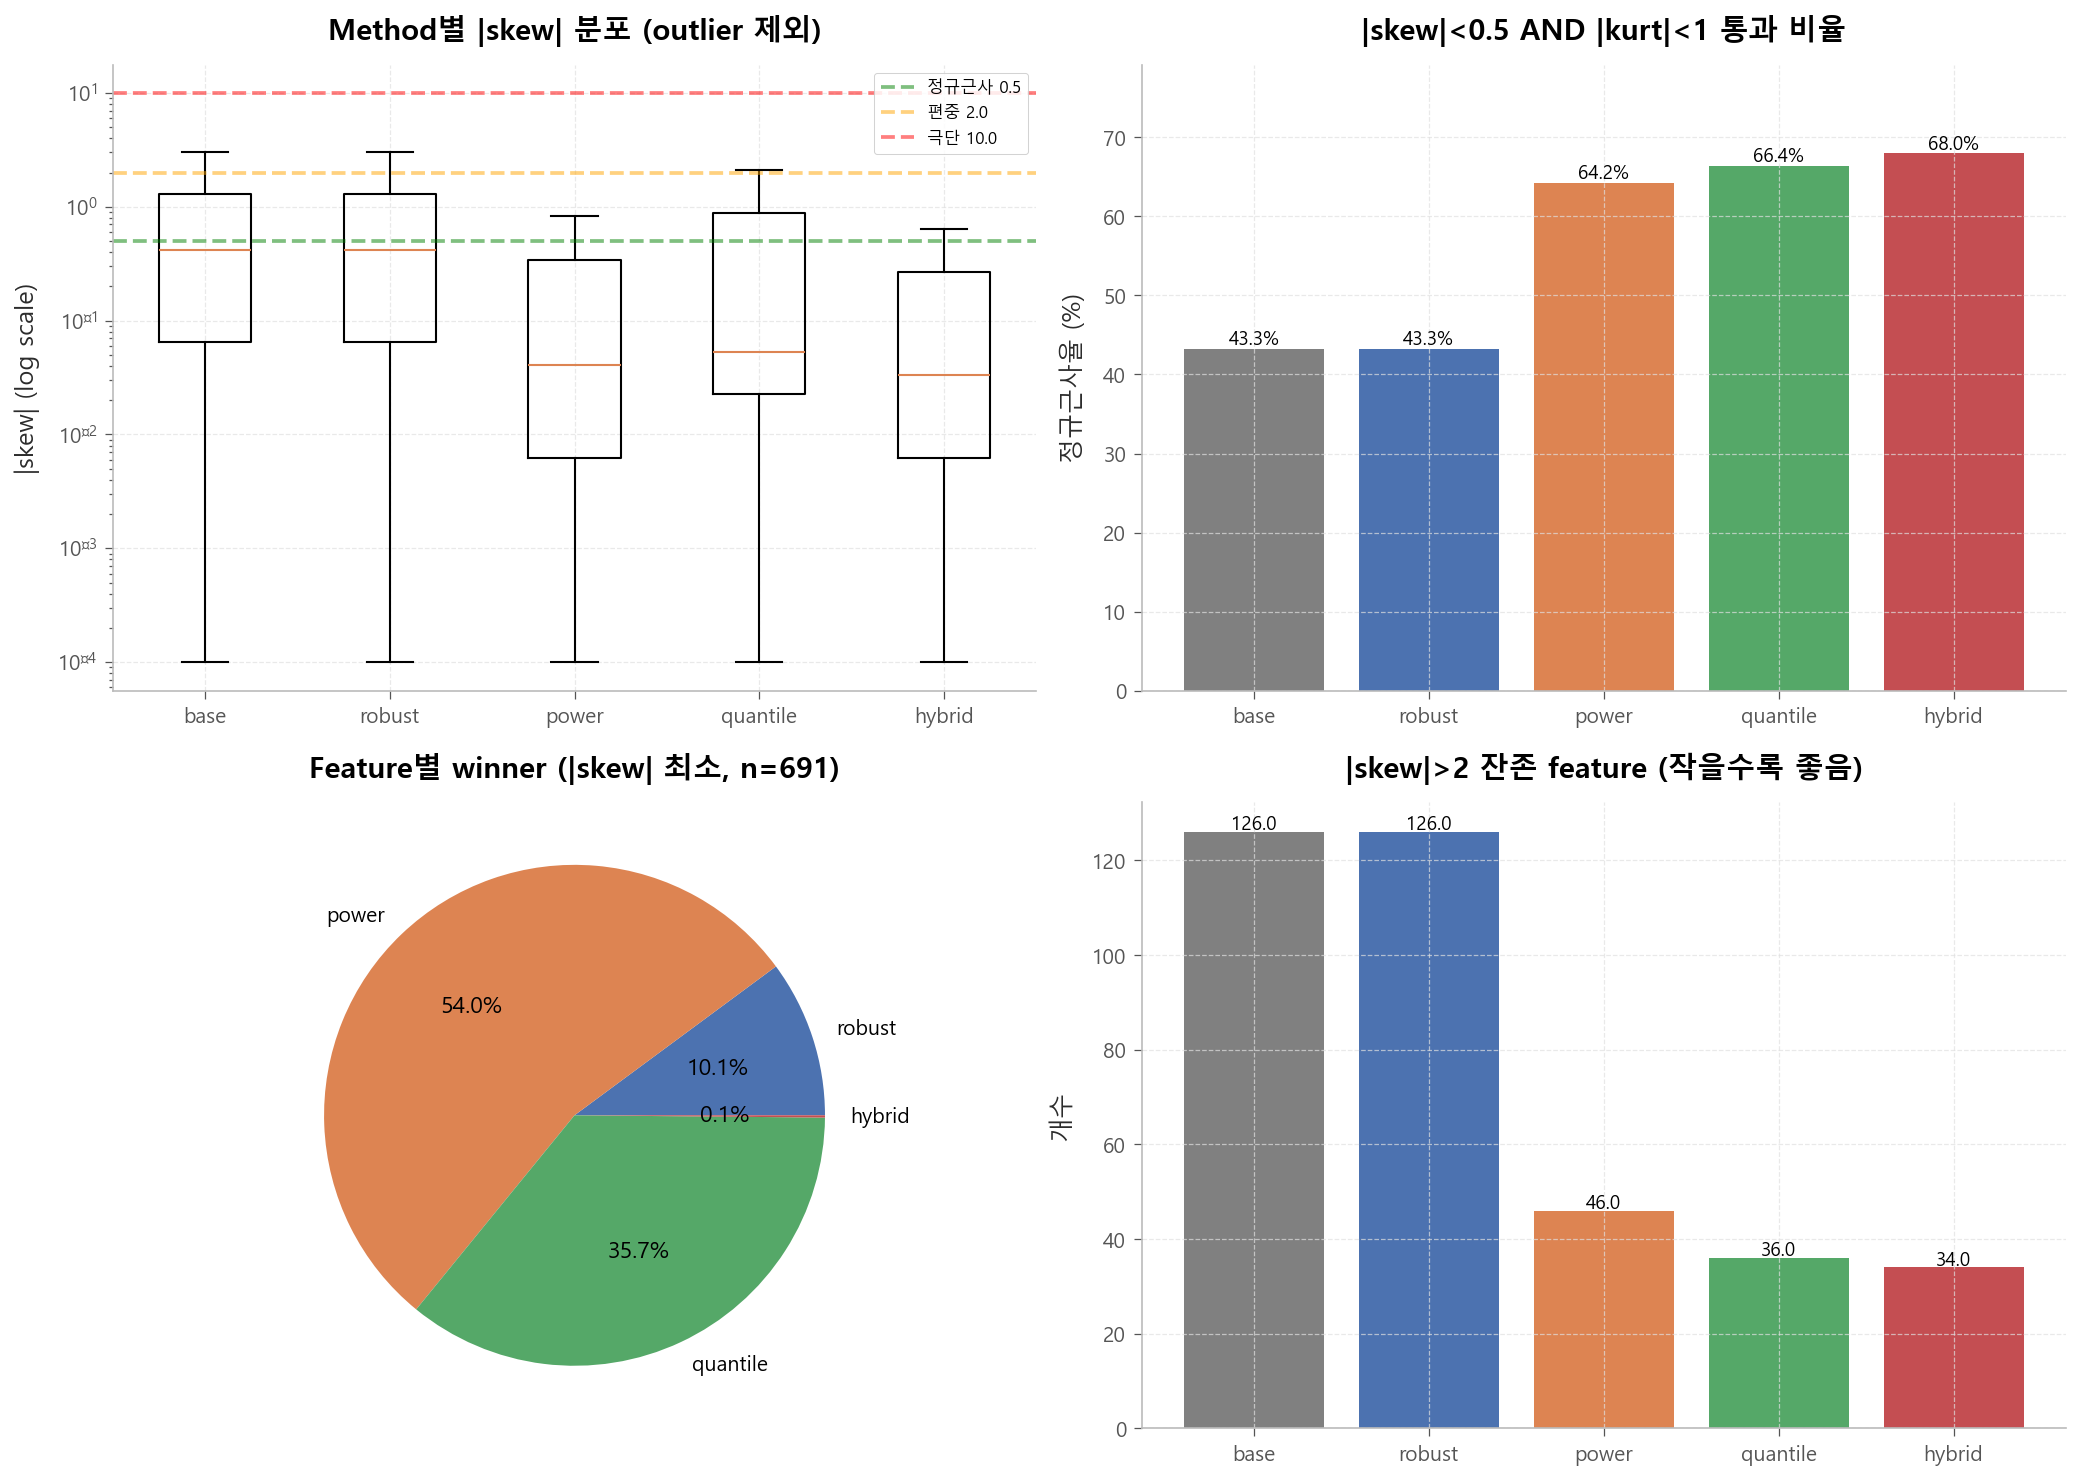

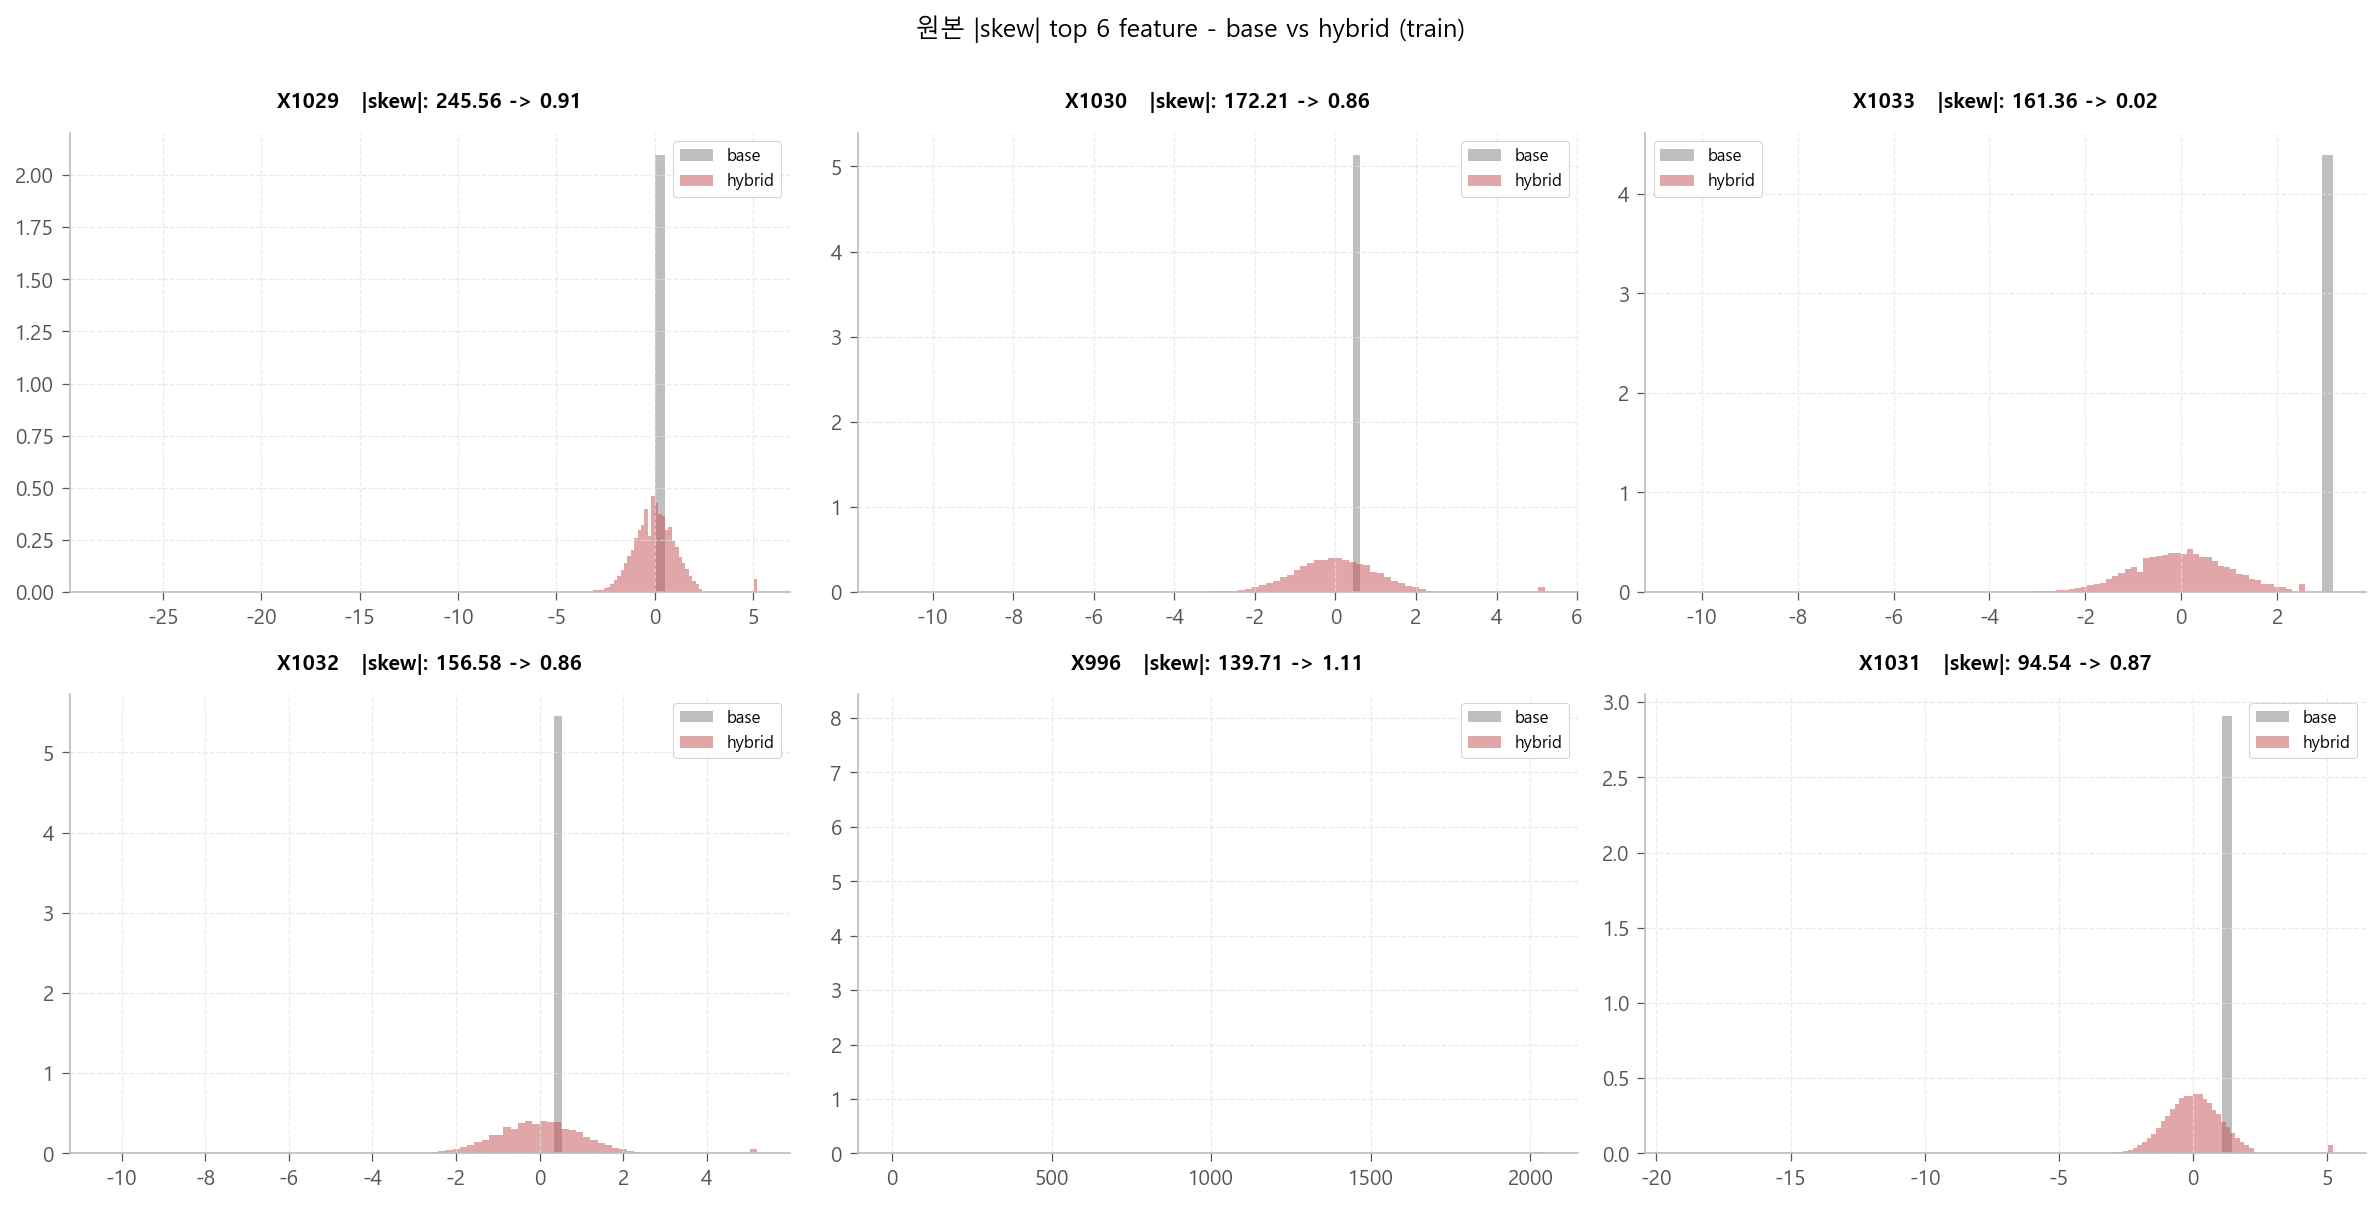

In [10]:
# -- Figure 1: 4-panel summary --
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) |skew| boxplot
ax = axes[0, 0]
data_box = [diags[m]['abs_skew'].clip(lower=1e-4).values for m in method_list]
ax.boxplot(data_box, labels=method_list, showfliers=False)
ax.set_yscale('log')
ax.set_ylabel('|skew| (log scale)')
ax.set_title('Method별 |skew| 분포 (outlier 제외)')
ax.axhline(0.5,  color='green',  linestyle='--', alpha=0.5, label='정규근사 0.5')
ax.axhline(2.0,  color='orange', linestyle='--', alpha=0.5, label='편중 2.0')
ax.axhline(10.0, color='red',    linestyle='--', alpha=0.5, label='극단 10.0')
ax.legend(fontsize=8)

# (0,1) 정규근사율 bar
ax = axes[0, 1]
rates = [summary.loc[m, '정규근사율(%)'] for m in method_list]
bars = ax.bar(method_list, rates, color=['gray', 'C0', 'C1', 'C2', 'C3'])
for b, v in zip(bars, rates):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_ylabel('정규근사율 (%)')
ax.set_title('|skew|<0.5 AND |kurt|<1 통과 비율')
ax.set_ylim(0, max(rates) * 1.15 + 1)

# (1,0) winner pie
ax = axes[1, 0]
ax.pie(winner_counts.values, labels=winner_counts.index,
       autopct='%1.1f%%', colors=['C0', 'C1', 'C2', 'C3'])
ax.set_title(f'Feature별 winner (|skew| 최소, n={len(winner)})')

# (1,1) |skew|>2 개수 비교 bar
ax = axes[1, 1]
counts_gt2 = [summary.loc[m, '|skew|>2'] for m in method_list]
bars = ax.bar(method_list, counts_gt2, color=['gray', 'C0', 'C1', 'C2', 'C3'])
for b, v in zip(bars, counts_gt2):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v}', ha='center', fontsize=9)
ax.set_ylabel('개수')
ax.set_title('|skew|>2 잔존 feature (작을수록 좋음)')

plt.tight_layout()
plt.show()

# -- Figure 2: top 6 high-skew feature before/after --
_tr_hybrid = scalers['hybrid'].transform(xs_train[feat_cols_scale].copy(), inplace=False)
top_feat = diag_base.nlargest(6, 'abs_skew').index.tolist()

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes2.flat, top_feat):
    ax.hist(xs_train[f].values,   bins=60, alpha=0.5, label='base',   color='gray', density=True)
    ax.hist(_tr_hybrid[f].values, bins=60, alpha=0.5, label='hybrid', color='C3',   density=True)
    sk_b = diag_base.loc[f, 'abs_skew']
    sk_h = diags['hybrid'].loc[f, 'abs_skew']
    ax.set_title(f'{f}   |skew|: {sk_b:.2f} -> {sk_h:.2f}', fontsize=10)
    ax.legend(fontsize=8)
fig2.suptitle('원본 |skew| top 6 feature - base vs hybrid (train)', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

del _tr_hybrid

## 10. 최종 권고안 + hybrid_scale 실제 적용

검증 결과를 바탕으로 `hybrid_scale()`을 **train fit → train/val/test transform** 으로 실적용.

- scaler 객체는 `joblib`으로 저장하면 대시보드/예측 파이프라인에서 재사용 가능 (strategy_2nd_ensemble.md §1.2 결정 3=B)
- `skew_threshold=10.0` 고정 (Optuna 탐색 X — strategy md §1 결정)

In [11]:
# -- 권고안 출력 --
print('=' * 72)
print('최종 권고안')
print('=' * 72)
print(f'- hybrid_scale 정규근사율 : {summary.loc["hybrid", "정규근사율(%)"]:.2f}%')
print(f'  (base: {summary.loc["base", "정규근사율(%)"]:.2f}%, '
      f'power: {summary.loc["power", "정규근사율(%)"]:.2f}%, '
      f'quantile: {summary.loc["quantile", "정규근사율(%)"]:.2f}%)')
print(f'- hybrid |skew|>10 잔존  : {summary.loc["hybrid", "|skew|>10"]}개 '
      f'(base: {summary.loc["base", "|skew|>10"]}개)')
print(f'- feature별 winner       : {dict(winner_counts)}')
print(f'- 잔존 문제 feature(best도 |skew|>2): {int(residual.sum())}개')
if residual.sum() > 0:
    print(f'  ↳ 상위 5개: {residual[residual].index[:5].tolist()}')

print()
print('=' * 72)
print('hybrid_scale 실적용 - 이미 fit된 scaler 재사용 (중복 학습 방지)')
print('=' * 72)

# 셀 6에서 scalers['hybrid']가 xs_train에 fit 완료 -> 재사용
scaler = scalers['hybrid']
print(f'[재사용] HybridScaler: quantile {len(scaler.quantile_cols_)}개 + '
      f'power {len(scaler.power_cols_)}개 feature')

# 3 split 모두 inplace transform
for split_name, df in [('train', xs_train), ('val', xs_val), ('test', xs_test)]:
    scaler.transform(df, inplace=True)
    n_nan = df[feat_cols_scale].isna().sum().sum()
    n_inf = int(np.isinf(df[feat_cols_scale].values).sum())
    print(f'  {split_name:5s}: shape={df.shape}, NaN={n_nan}, Inf={n_inf}')
    assert n_nan == 0 and n_inf == 0, f'{split_name}에 NaN/Inf 발생'

print()
print('scaler는 joblib.dump(scaler, "hybrid_scaler.pkl")로 저장 가능')
print('-> 2차 앙상블 노트북 / 대시보드에서 재사용')

최종 권고안
- hybrid_scale 정규근사율 : 68.02%
  (base: 43.27%, power: 64.25%, quantile: 66.43%)
- hybrid |skew|>10 잔존  : 1.0개 (base: 28.0개)
- feature별 winner       : {'robust': np.int64(70), 'power': np.int64(373), 'quantile': np.int64(247), 'hybrid': np.int64(1)}
- 잔존 문제 feature(best도 |skew|>2): 29개
  ↳ 상위 5개: ['X364', 'X365', 'X366', 'X367', 'X368']

hybrid_scale 실적용 - 이미 fit된 scaler 재사용 (중복 학습 방지)
[재사용] HybridScaler: quantile 51개 + power 593개 feature
  train: shape=(104988, 730), NaN=0, Inf=0
  val  : shape=(34996, 730), NaN=0, Inf=0
  test : shape=(34996, 730), NaN=0, Inf=0

scaler는 joblib.dump(scaler, "hybrid_scaler.pkl")로 저장 가능
-> 2차 앙상블 노트북 / 대시보드에서 재사용


## 10.5 (진단 부록) 극단 feature 원본 분포 조사

4종 스케일링 중 **어느 것도 \|skew\|>2로 못 내린 36개 feature**의 원본 분포를 train/val/test 전부에서 확인.

**⚠ 원칙상 val/test 값 참조는 data leakage 위험** — 여기서는 **scaler 파라미터 학습에 반영하지 않음**. 순수 **분포 진단**용.

**판정 기준**
- `nunique ≤ 5`: 사실상 이산형/상수 → `EXCLUDE_COLS` 추가 또는 `const_threshold` 완화 후보
- `top% > 99`: 최빈값 한 점에 거의 몰림 → 동일 결론
- 3-split 간 nunique/top% 유사: 분포 drift 없음 (정상)
- 3-split 간 차이 큼: split이 다른 분포를 보는 feature (drift 위험)

In [12]:
# ============================================================
# 진단: 극단 feature의 원본 분포 (train/val/test)
# ⚠ scaler 파라미터에는 반영하지 않음 — 진단/판단 용도만
# ============================================================
diag_cols = residual[residual].index.tolist()   # 4종 best도 |skew|>2인 feature (36개)
print(f'진단 대상: {len(diag_cols)}개 feature (4종 스케일링 어느 것도 |skew|≤2 못 만듦)')

rows = []
for f in diag_cols:
    row = {'feature': f}
    for split_name, df in [('train', xs_dict['train']),
                           ('val',   xs_dict['validation']),
                           ('test',  xs_dict['test'])]:
        s = df[f].dropna()
        if len(s) == 0:
            row[f'{split_name}_nuniq']  = 0
            row[f'{split_name}_top%']   = np.nan
            row[f'{split_name}_skew']   = np.nan
            continue
        row[f'{split_name}_nuniq'] = int(s.nunique())
        row[f'{split_name}_top%']  = round(float(s.value_counts(normalize=True).iloc[0]) * 100, 2)
        row[f'{split_name}_skew']  = round(float(s.skew()), 2)
    rows.append(row)

diag_df = pd.DataFrame(rows).set_index('feature')
# base |skew|가 큰 순으로 정렬
diag_df['base_abs_skew'] = diag_df.index.map(diag_base['abs_skew'])
diag_df = diag_df.sort_values('base_abs_skew', ascending=False)
diag_df = diag_df.drop(columns=['base_abs_skew'])

print('\n── 원본 xs_dict 기준 (cleaning/outlier/scaling 이전) ──')
print(diag_df.to_string())

# ── 요약 판정 ──
print('\n── 판정 요약 ──')
almost_constant  = diag_df[diag_df['train_top%'] > 99.0]
very_few_unique  = diag_df[diag_df['train_nuniq'] <= 5]
discrete_like    = diag_df[diag_df['train_nuniq'] <= 20]
print(f'  train_top% > 99% (거의 상수)        : {len(almost_constant)}개 → {almost_constant.index.tolist()}')
print(f'  train_nuniq ≤ 5                       : {len(very_few_unique)}개 → {very_few_unique.index.tolist()}')
print(f'  train_nuniq ≤ 20 (이산형 유사)        : {len(discrete_like)}개 → {discrete_like.index.tolist()}')

# split 간 drift (nuniq 차이 > 30%)
drift_mask = (
    (diag_df[['train_nuniq', 'val_nuniq', 'test_nuniq']].std(axis=1) /
     diag_df[['train_nuniq', 'val_nuniq', 'test_nuniq']].mean(axis=1)) > 0.3
)
print(f'\n  split 간 nuniq 변동 > 30% (drift 의심): {int(drift_mask.sum())}개')
if drift_mask.sum() > 0:
    print(f'  → {diag_df[drift_mask].index.tolist()}')

# 추천 행동
print('\n── 추천 ──')
to_exclude = set(almost_constant.index) | set(very_few_unique.index)
if len(to_exclude) > 0:
    print(f'  ✓ EXCLUDE_COLS 추가 후보 ({len(to_exclude)}개): {sorted(to_exclude)}')
else:
    print(f'  - 거의 상수 feature 없음 → 현재 상태 유지 + 트리 모델에서 자동 처리 기대')

remainder = set(diag_df.index) - to_exclude
if len(remainder) > 0:
    print(f'  ⚠ 잔존 {len(remainder)}개는 이산형 아니지만 skew 높음 → FS 단계에서 제거 후보')

진단 대상: 29개 feature (4종 스케일링 어느 것도 |skew|≤2 못 만듦)

── 원본 xs_dict 기준 (cleaning/outlier/scaling 이전) ──
         train_nuniq  train_top%  train_skew  val_nuniq  val_top%  val_skew  test_nuniq  test_top%  test_skew
feature                                                                                                      
X954               5       99.04      -23.61          4     98.95    -22.46           4      99.04     -23.15
X921               6       99.01      -23.90          4     99.08    -25.43           6      98.97      26.79
X368               2       98.74        8.74          2     98.76      8.80           2      98.73       8.69
X922               6       98.72        7.30          5     98.79      8.08           5      98.73       7.16
X514              19       98.34       24.80         11     98.28     18.77          14      98.35      24.68
X945               7       98.34       52.13          5     98.42     56.01           5      98.39      55.41
X923               5

## 11. LDS sanity check (2차 funnel 준비)

`compute_lds_weights()`는 **2차 앙상블 funnel의 회귀 학습에 사용** (Stage 2 Y>0 long-tail 대응).

여기서는 회귀 학습 없이 **weights 분포만 sanity check** — 실제 RMSE 개선 효과는 2차 노트북에서.

검증 항목:
- `weights.mean() ≈ 1` (정규화 확인)
- y=0 샘플은 weight=1 (only_positive=True)
- y>0 샘플만 재가중
- 극단값 클립 비율 확인 (`max_weight=10.0` 상한)

sigma=0.005 | mean=1.0000 | min=0.4355 max=24.8392 | std(y>0)=2.4947 | clip_low=0.0% clip_high=1.4%
sigma=0.010 | mean=1.0000 | min=0.6832 max=25.7299 | std(y>0)=1.8948 | clip_low=0.0% clip_high=0.7%
sigma=0.020 | mean=1.0000 | min=0.8979 max=20.9980 | std(y>0)=0.9288 | clip_low=0.0% clip_high=0.2%


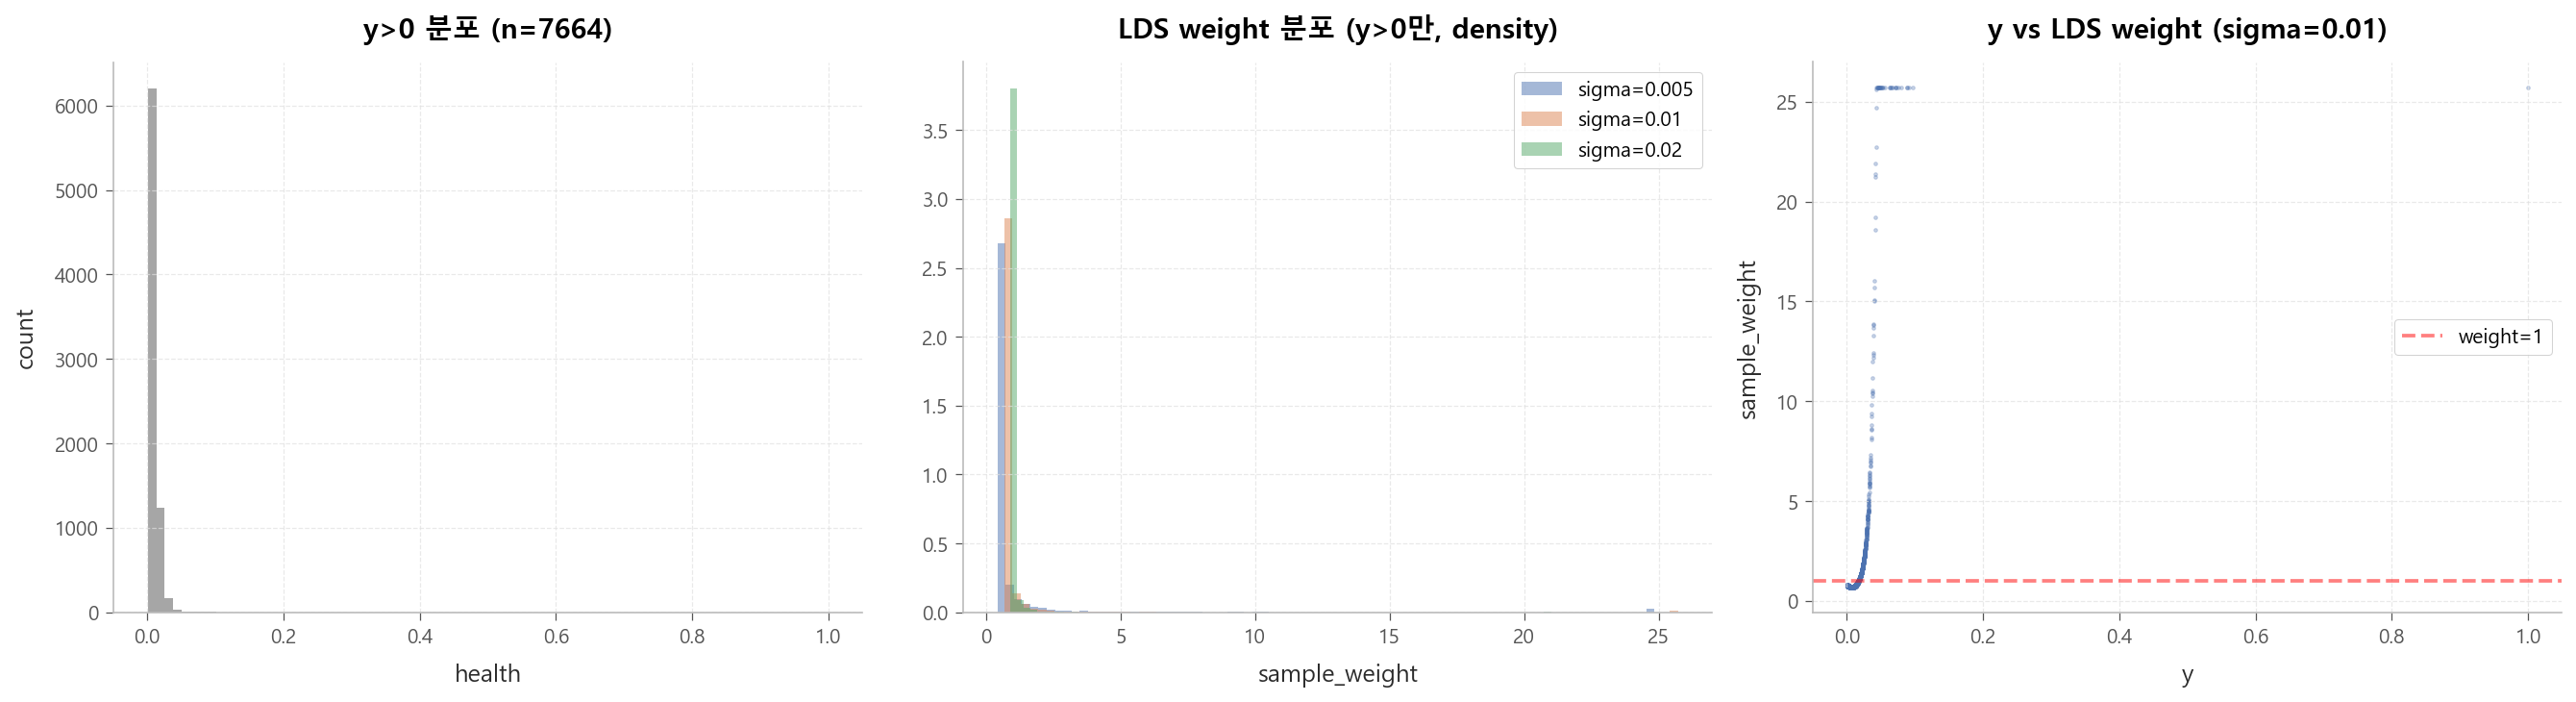


✓ sanity OK: weights.mean()=1.0000, y=0 샘플 weight==1 비율=1.000


In [13]:
y_train_unit = ys['train'][TARGET_COL].values

# sigma 후보 3개 비교 (strategy md PP_LDS_CANDIDATES)
sigmas = [0.005, 0.01, 0.02]
lds_results = {}
for s in sigmas:
    w, info = compute_lds_weights(
        y_train_unit, sigma=s,
        min_weight=0.1, max_weight=10.0,
        only_positive=True, expand_to_die=False,
    )
    lds_results[s] = (w, info)
    print(f'sigma={s:.3f} | mean={w.mean():.4f} | min={w.min():.4f} '
          f'max={w.max():.4f} | std(y>0)={info["weight_std"]:.4f} | '
          f'clip_low={info["clip_low_ratio"]*100:.1f}% '
          f'clip_high={info["clip_high_ratio"]*100:.1f}%')

# ── 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) y 분포 (reference)
ax = axes[0]
y_pos = y_train_unit[y_train_unit > 0]
ax.hist(y_pos, bins=80, color='gray', alpha=0.7)
ax.set_title(f'y>0 분포 (n={len(y_pos)})')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('count')

# (2) sigma별 weight 분포 (y>0만)
ax = axes[1]
for s in sigmas:
    w, _ = lds_results[s]
    ax.hist(w[y_train_unit > 0], bins=80, alpha=0.5, label=f'sigma={s}', density=True)
ax.set_title('LDS weight 분포 (y>0만, density)')
ax.set_xlabel('sample_weight')
ax.legend()

# (3) y vs weight scatter (sigma=0.01 기준)
ax = axes[2]
w_mid, _ = lds_results[0.01]
ax.scatter(y_train_unit[y_train_unit > 0], w_mid[y_train_unit > 0],
           s=3, alpha=0.3)
ax.set_title('y vs LDS weight (sigma=0.01)')
ax.set_xlabel('y')
ax.set_ylabel('sample_weight')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='weight=1')
ax.legend()

plt.tight_layout()
plt.show()

# sanity assertions
# sanity assertions — sigma=0.01 결과 재사용 (중복 KDE fit 방지)
w_default = lds_results[0.01][0]
assert abs(w_default.mean() - 1.0) < 0.05, f'weights.mean()={w_default.mean():.4f} (~1이어야)'
assert np.all(w_default[y_train_unit == 0] == 1.0), 'y=0 샘플은 weight=1이어야 함'
print(f'\n✓ sanity OK: weights.mean()={w_default.mean():.4f}, '
      f'y=0 샘플 weight==1 비율={(w_default[y_train_unit==0]==1.0).mean():.3f}')